In [ ]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load Dataset

df = pd.read_csv("StudentPerformanceFactors.csv")

# Display first 5 rows
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [ ]:
# Dataset Information

print("Shape of dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
print(df.info())

Shape of dataset: (6607, 20)

Column Names:
Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  66

In [ ]:
# Check Missing Values

print(df.isnull().sum())

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


In [ ]:
# Check Duplicates

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
# Summary Statistics

df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


Exploratory Data Analysis (EDA)

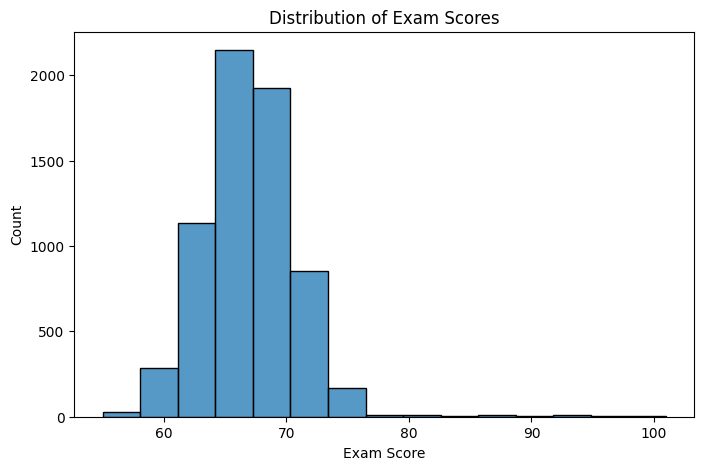

In [ ]:
# Distribution of Exam Scores

plt.figure(figsize=(8,5))

sns.histplot(df['Exam_Score'], bins=15)

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Count")

plt.show()

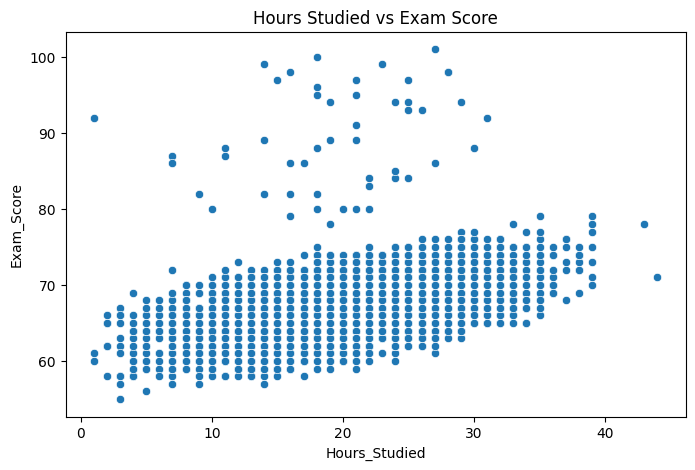

In [ ]:
# Hours Studied vs Exam Score

plt.figure(figsize=(8,5))

sns.scatterplot(x='Hours_Studied', y='Exam_Score', data=df)

plt.title("Hours Studied vs Exam Score")

plt.show()

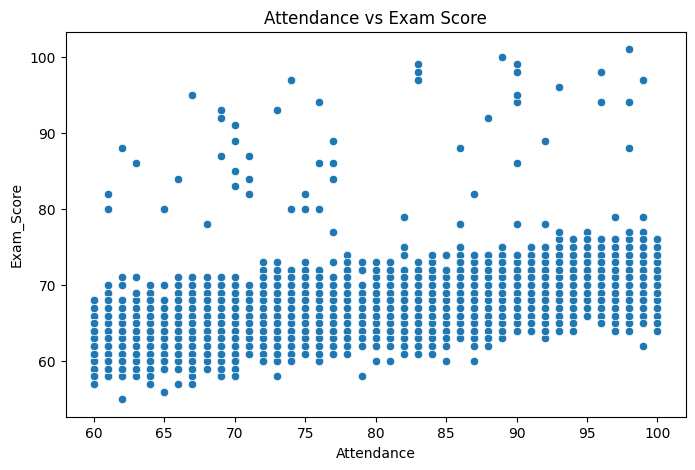

In [ ]:
# Attendance vs Exam Score

plt.figure(figsize=(8,5))

sns.scatterplot(x='Attendance', y='Exam_Score', data=df)

plt.title("Attendance vs Exam Score")

plt.show()

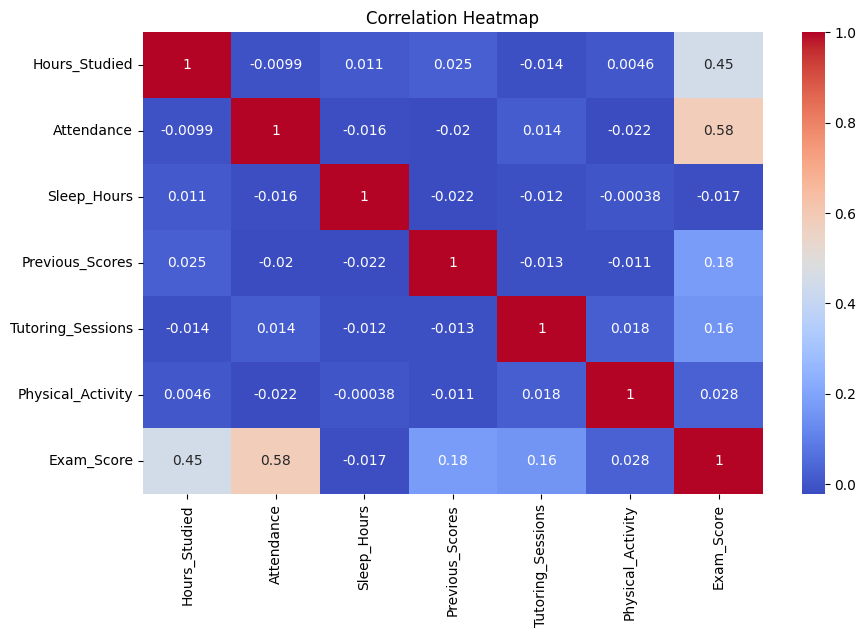

In [ ]:
# Correlation Heatmap

plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

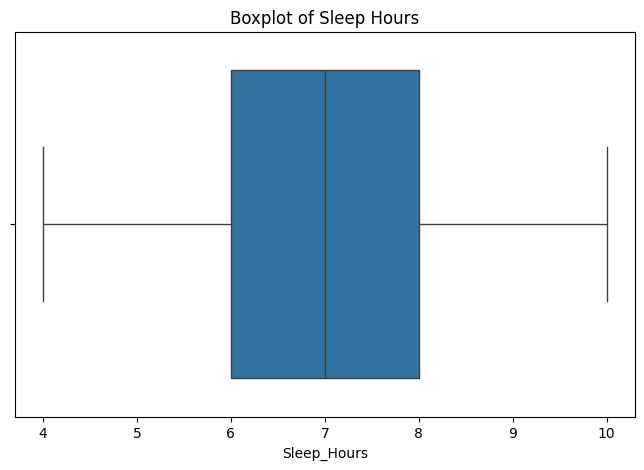

In [ ]:
# Sleep Hours Distribution

plt.figure(figsize=(8,5))

sns.boxplot(x=df['Sleep_Hours'])

plt.title("Boxplot of Sleep Hours")

plt.show()

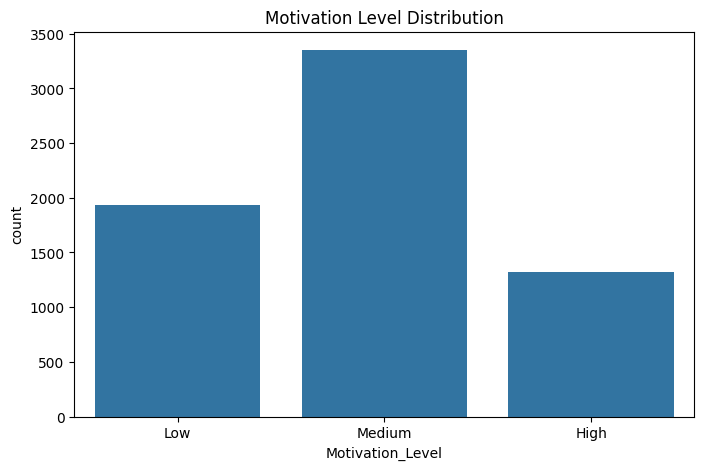

In [ ]:
# Motivation Level Count

plt.figure(figsize=(8,5))

sns.countplot(x='Motivation_Level', data=df)

plt.title("Motivation Level Distribution")

plt.show()

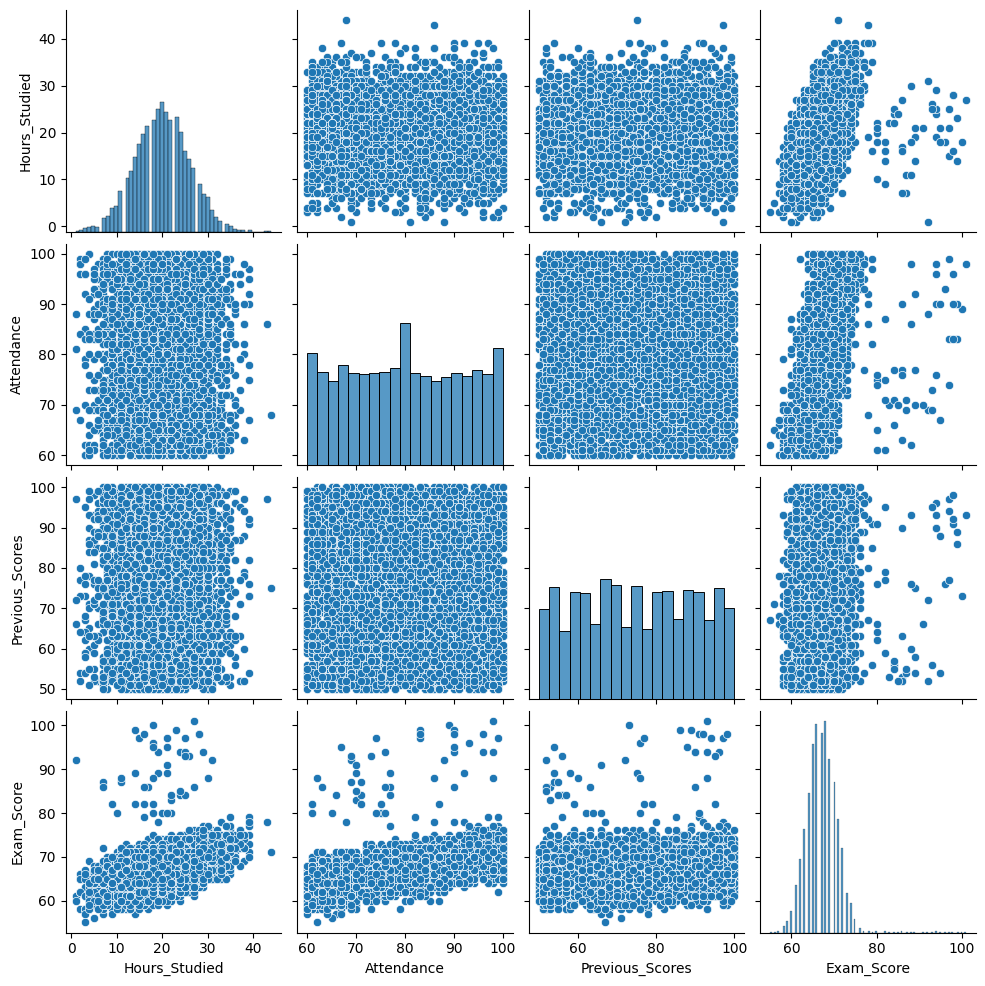

In [ ]:
# Pairplot

sns.pairplot(df[['Hours_Studied',
                 'Attendance',
                 'Previous_Scores',
                 'Exam_Score']])

plt.show()

Feature Selection

In [ ]:
# Define Features and Target Variable

X = df.drop('Exam_Score', axis=1)

y = df['Exam_Score']

In [ ]:
# Convert categorical columns into numerical values

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Select categorical columns
categorical_cols = df.select_dtypes(include='object').columns

# Apply Label Encoding
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Display first 5 rows
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,1,0,0,7,73,1,1,0,1,2,1,2,3,0,1,2,1,67
1,19,64,1,2,0,8,59,1,1,2,2,2,1,0,4,0,0,1,0,61
2,24,98,2,2,1,7,91,2,1,2,2,2,1,1,4,0,2,2,1,74
3,29,89,1,2,1,8,98,2,1,1,2,2,1,0,4,0,1,1,1,71
4,19,92,2,2,1,6,65,2,1,3,2,0,1,1,4,0,0,2,0,70


In [ ]:
# Features and Target Variable

X = df.drop('Exam_Score', axis=1)

y = df['Exam_Score']

In [ ]:
# Split Dataset into Training and Testing Data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (5285, 19)
Testing Data Shape: (1322, 19)


In [ ]:
# Linear Regression Model

from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Predictions

y_pred_lr = lr_model.predict(X_test)

print(y_pred_lr[:5])

[65.20083182 67.44490122 69.78414258 67.2956279  66.74660215]


In [ ]:
# Model Evaluation

from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred_lr)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred_lr)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 2.097948359816075
R2 Score: 0.688619401927732


In [ ]:
# Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [ ]:
# Random Forest Evaluation

mse_rf = mean_squared_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2 Score:", r2_rf)

Random Forest RMSE: 2.213780301292411
Random Forest R2 Score: 0.6532863038564358


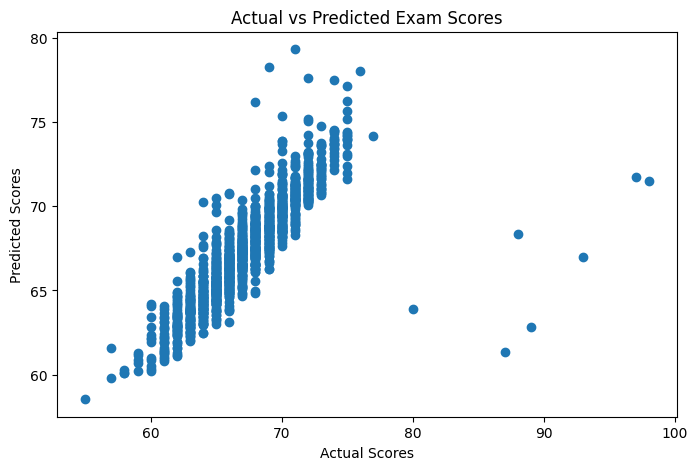

In [ ]:
# Actual vs Predicted Values

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")

plt.title("Actual vs Predicted Exam Scores")

plt.show()

In [ ]:
# Feature Importance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance)

                       Feature  Importance
1                   Attendance    0.381449
0                Hours_Studied    0.242662
6              Previous_Scores    0.091385
9            Tutoring_Sessions    0.035440
3          Access_to_Resources    0.028868
5                  Sleep_Hours    0.028611
14           Physical_Activity    0.028010
2         Parental_Involvement    0.026583
10               Family_Income    0.019824
13              Peer_Influence    0.018788
17          Distance_from_Home    0.017211
16    Parental_Education_Level    0.015887
11             Teacher_Quality    0.012522
7             Motivation_Level    0.012154
15       Learning_Disabilities    0.009762
4   Extracurricular_Activities    0.009390
12                 School_Type    0.008524
18                      Gender    0.007425
8              Internet_Access    0.005504


# Conclusion

This project analyzed various factors affecting student performance.

Key findings:
- Students with higher attendance and study hours generally performed better.
- Previous scores strongly influenced exam performance.
- Random Forest Regressor performed better than Linear Regression.

The project successfully demonstrated the use of data preprocessing, visualization, and machine learning techniques for predicting student exam scores.